# HI-VIS — Dual Inference: Segmentation + YOLOv26 Pose

**Derived from `YOLO8.ipynb` — sequential segmentation and pose on the same image, fused overlay.**

> This notebook (`yolo-pose.ipynb`) copies the setup/data cells from `YOLO8.ipynb` and adds a YOLOv26 pose branch.
> **Do not edit `YOLO8.ipynb` for this task** — that file remains the unchanged source.

Pipeline (sequential, same `sample_image`):
```
sample_image ─┬─▶ segmentation model (best.pt / yolov8n-seg) ─┐
              └─▶ YOLO26 pose model (yolo26s-pose.pt) ──────┤─▶ fused overlay (masks + skeletons)
```

- Segmentation branch = copied from `YOLO8.ipynb` cell 7 (reference `best.pt` detection; swap to a `-seg` weight when available).
- Pose branch = `yolo26s-pose.pt` (Ultralytics; fallback `yolov8s-pose.pt` if yolo26 not yet published).
- Visualization = single fused image: masks (alpha 0.4) + keypoint skeletons.


## 1 · Setup

In [142]:
# Core
import os
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import time

# Modelling (transfer learning baseline)
# import tensorflow as tf
# from tensorflow.keras import layers, Sequential
# from tensorflow.keras.applications.vgg16 import VGG16

# Object detection
# from ultralytics import YOLO   # pip install ultralytics

sns.set_theme(style="whitegrid")
RANDOM_STATE = int(time.time())
print(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


1787641323


## 2 · Data (copied from `YOLO8.ipynb`)

Uses `data/css-data` — same `DATA_DIR`, `CLASS_NAMES`, `data.yaml`.


In [143]:
DATA_DIR = Path("data/css-data")

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    n_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob("*"))) if lbl_dir.exists() else 0
    print(f"{split:6s} images={n_img:5d}  labels={n_lbl:5d}")


train  images= 2605  labels= 2605
valid  images=  114  labels=  114
test   images=   82  labels=   82


In [144]:
# The Roboflow export doesn't always ship its own data.yaml (ours didn't) — write one.
# Class order below matches ppe_data.yaml from the reference notebook's run, so it's
# consistent with results_yolov8n_100e's weights too.
import yaml


# TODO: fix the path to point it at your downloaded data folder

CLASS_NAMES = [
    "Hardhat", "Mask", "NO-Hardhat", "NO-Mask", "NO-Safety Vest",
    "Person", "Safety Cone", "Safety Vest", "machinery", "vehicle",
]

data_cfg = {
    "train": str((DATA_DIR / "train" / "images").resolve()),
    "val": str((DATA_DIR / "valid" / "images").resolve()),
    "test": str((DATA_DIR / "test" / "images").resolve()),
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

yaml_path = DATA_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_cfg, f)

print(f"wrote {yaml_path}")
print(data_cfg)


wrote data\css-data\data.yaml
{'train': 'E:\\work\\P0-safety\\data\\css-data\\train\\images', 'val': 'E:\\work\\P0-safety\\data\\css-data\\valid\\images', 'test': 'E:\\work\\P0-safety\\data\\css-data\\test\\images', 'nc': 10, 'names': ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']}


## 3 · Helpers (copied)


In [145]:
def parse_yolo_labels(label_path, class_names):
    """Read a YOLO-format .txt label file into a list of (class_name, x, y, w, h) — all normalised 0-1."""
    rows = []
    if not Path(label_path).exists():
        return rows
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id, x, y, w, h = int(parts[0]), *map(float, parts[1:5])
            rows.append((class_names[cls_id], x, y, w, h))
    return rows


## 4 · Segmentation branch — same image, shared `sample_image`

Copied from `YOLO8.ipynb` cell 7. `REFERENCE_WEIGHTS` (`runs/detect/train/weights/best.pt`) is a **detection** checkpoint. If a segmentation weight (`*-seg.pt`) is available, replace `SEG_WEIGHTS` accordingly — no other code changes needed.


segmentation model: data\results_yolov8n_100e\kaggle\working\runs\detect\train\weights\best.pt  task=detect
sample_image: data\css-data\test\images\youtube-213_jpg.rf.da70b1d8cefd3cc9d56e43bb88dfb67d.jpg
seg inference: 48.7 ms  detections=4


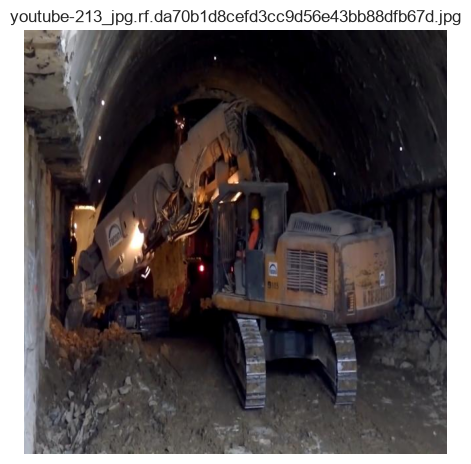

In [146]:
# ── Segmentation branch (copied & lightly adapted from YOLO8.ipynb cell 7) ──
from ultralytics import YOLO
import time

REFERENCE_WEIGHTS = DATA_DIR.parent / "results_yolov8n_100e" / "kaggle" / "working" / "runs" / "detect" / "train" / "weights" / "best.pt"
SEG_WEIGHTS = REFERENCE_WEIGHTS  # swap to a *-seg.pt when available without changing below

seg_model = YOLO(str(SEG_WEIGHTS))
print(f"segmentation model: {SEG_WEIGHTS}  task={seg_model.task}")

test_images = list((DATA_DIR / "test" / "images").glob("*"))
assert test_images, f"No images in {DATA_DIR / 'test' / 'images'}"
sample_image = random.choice(test_images)
print(f"sample_image: {sample_image}")

t0 = time.perf_counter()
seg_results = seg_model(str(sample_image), verbose=False)
seg_ms = (time.perf_counter() - t0) * 1000
print(f"seg inference: {seg_ms:.1f} ms  detections={len(seg_results[0].boxes) if seg_results[0].boxes is not None else 0}")

img_bgr = cv2.imread(str(sample_image))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.title(sample_image.name)
plt.tight_layout()
plt.show()

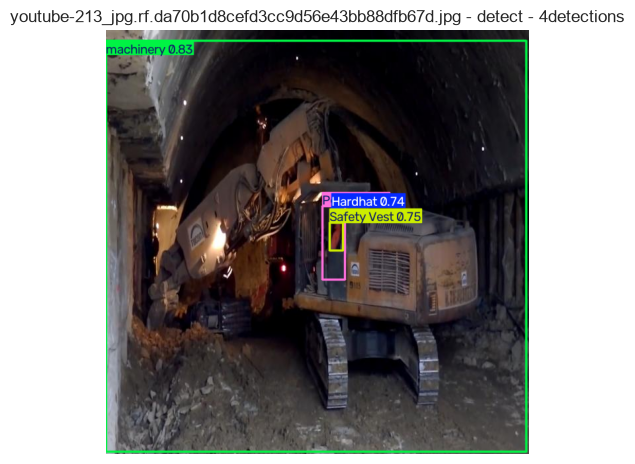

has masks: False


In [147]:
# ── Visualize segmentation branch with plt ──
import cv2
import matplotlib.pyplot as plt
# 1. Ultralytics renders boxes + masks (if weight is *-seg.pt) to BGR numpyarray
annotated_bgr = seg_results[0].plot() # masks=True by default for seg task
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)
# 2. Show with plt
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title(f"{sample_image.name} - {seg_model.task} - {len(seg_results[0].boxes) if seg_results[0].boxes is not None else 0}detections")
plt.tight_layout()
plt.show()
# optional check: do you have real masks?
print("has masks:", seg_results[0].masks is not None)
if seg_results[0].masks is not None:
    print("masks shape:", seg_results[0].masks.data.shape)

In [148]:
# ── Segmentation annotation results as table ──
import pandas as pd
import numpy as np

r = seg_results[0]  # single image result
names = r.names  # {id: name}

rows = []
if r.boxes is not None and len(r.boxes) > 0:
    has_masks = r.masks is not None
    polygons = r.masks.xy if has_masks else [None] * len(r.boxes)
    for i in range(len(r.boxes)):
        cls_id = int(r.boxes.cls[i].item())
        x1, y1, x2, y2 = r.boxes.xyxy[i].tolist()
        rows.append({
            "idx": i,
            "class_id": cls_id,
            "class_name": names[cls_id],
            "conf": round(float(r.boxes.conf[i].item()), 4),
            "x1": round(x1, 1),
            "y1": round(y1, 1),
            "x2": round(x2, 1),
            "y2": round(y2, 1),
            "w": round(x2 - x1, 1),
            "h": round(y2 - y1, 1),
            "has_mask": has_masks,
            "mask_points": len(polygons[i]) if polygons[i] is not None else 0,
            "mask_area_px": int((r.masks.data[i].cpu().numpy() > 0.5).sum()) if has_masks else None,
        })

df = pd.DataFrame(rows, columns=["idx","class_name","class_id","conf","x1","y1","x2","y2","w","h","has_mask","mask_points","mask_area_px"])
display(df)
print(f"image: {sample_image.name}  detections={len(df)}  task={seg_model.task}  has_masks={r.masks is not None}")
# df.to_csv("seg_results_table.csv", index=False)  # uncomment to save


,idx,class_name,class_id,conf,x1,y1,x2,y2,w,h,has_mask,mask_points,mask_area_px
0,0,machinery,8,0.8257,0.0,15.5,635.9,636.5,635.9,621.0,False,0,None
1,1,Safety Vest,7,0.7522,338.1,290.1,358.6,332.1,20.5,42.0,False,0,None
2,2,Hardhat,0,0.7421,341.5,267.4,358.3,286.2,16.9,18.8,False,0,None
3,3,Person,5,0.7171,327.6,265.3,361.5,376.4,34.0,111.1,False,0,None


image: youtube-213_jpg.rf.da70b1d8cefd3cc9d56e43bb88dfb67d.jpg  detections=4  task=detect  has_masks=False



image 1/1 e:\work\P0-safety\data\css-data\test\images\youtube-213_jpg.rf.da70b1d8cefd3cc9d56e43bb88dfb67d.jpg: 640x640 (no detections), 191.9ms
Speed: 1.7ms preprocess, 191.9ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


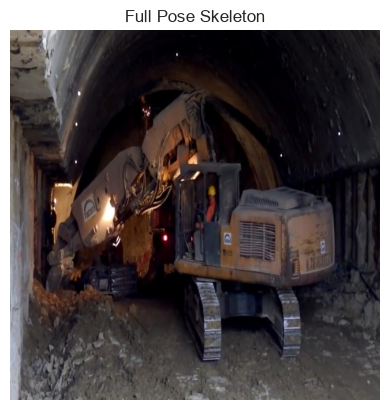

""


In [149]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd

model = YOLO("yolo26m-pose.pt")
results = model(str(sample_image))

for result in results:
    # plot() automatically draws the 17 keypoints and connects the bones
    annotated_frame = result.plot()

    # cv2.imshow doesn't work in notebooks — use plt instead
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Full Pose Skeleton")
    plt.show()

# ── same result as table ──
r = results[0]
rows = []
if r.boxes is not None and len(r.boxes) > 0:
    for i in range(len(r.boxes)):
        x1, y1, x2, y2 = r.boxes.xyxy[i].tolist()
        rows.append({
            "idx": i,
            "class": r.names[int(r.boxes.cls[i])],
            "conf": round(float(r.boxes.conf[i]), 4),
            "x1": round(x1,1), "y1": round(y1,1),
            "x2": round(x2,1), "y2": round(y2,1),
        })
display(pd.DataFrame(rows))


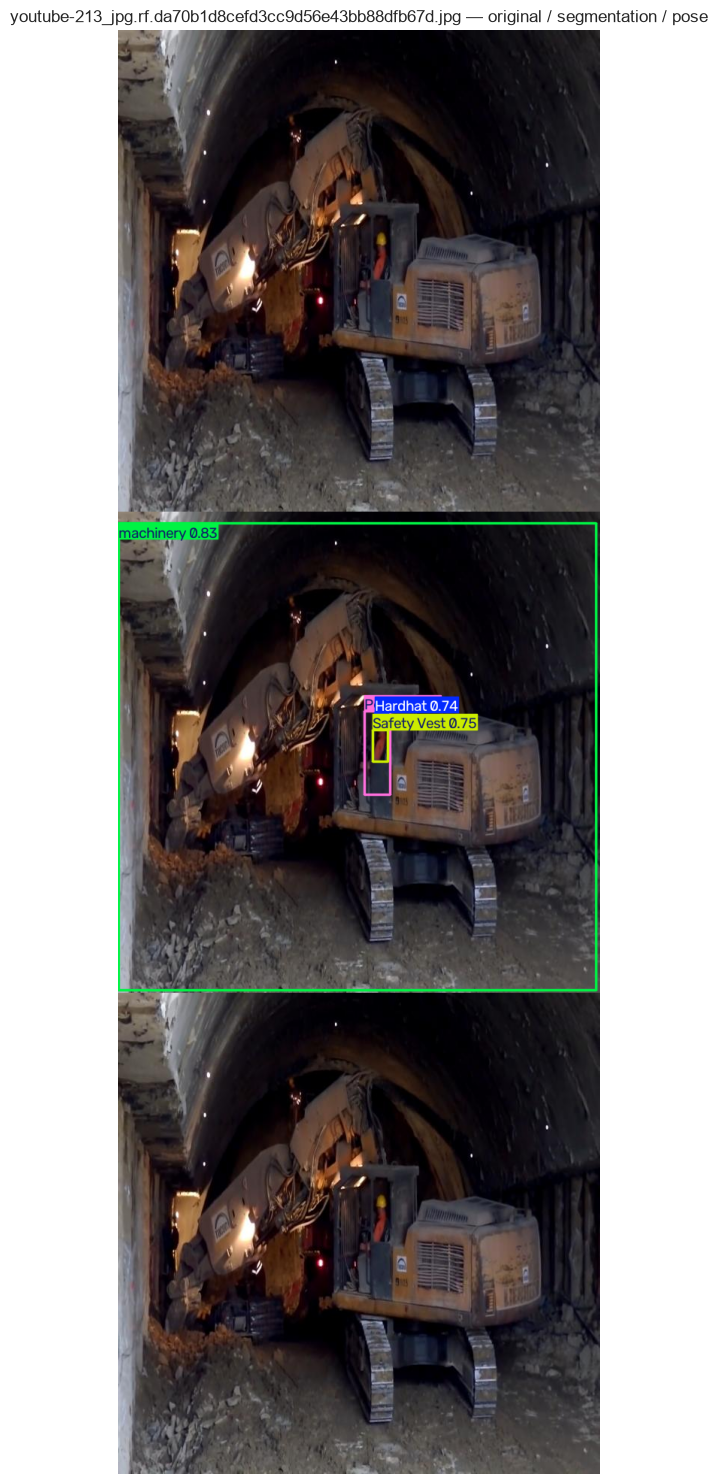

saved combined_vertical.jpg  shape=(1920, 640, 3)


In [150]:
# -- Combine vertically: original + segmentation + pose (one image) --
import cv2
import matplotlib.pyplot as plt
import numpy as np

# reuse same sample_image + already-run results (no re-inference)
orig_bgr = cv2.imread(str(sample_image))
orig = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
seg = cv2.cvtColor(seg_results[0].plot(), cv2.COLOR_BGR2RGB)  # segmentation branch
pose = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)     # pose branch (results from previous cell)

# stack vertically — all three have same WxH since they come from same image
combined = np.vstack([orig, seg, pose])

plt.figure(figsize=(10, 15))
plt.imshow(combined)
plt.axis("off")
plt.title(f"{sample_image.name} — original / segmentation / pose")
plt.tight_layout()
plt.show()

# save one file for report
cv2.imwrite("combined_vertical.jpg", cv2.cvtColor(combined, cv2.COLOR_RGB2BGR))
print(f"saved combined_vertical.jpg  shape={combined.shape}")
